# Proceso 2D-1D Wavelet Denoising

# 0. Importaciones y Configuración

In [2]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
import os

import sys

sys.path.append('../../src')

from wavelet_denoising import Wavelet2D1DTransform, Denoiser2D1D
from dicts_wavelets import transformaciones_1d, transformaciones_2d, filtros

DATA_DIR = '/Users/kuky/Documents/practica/WALDO/data'

## 0.1. Definición de funciones

In [3]:
def wavelet_denoising(
    cube_name,
    cube_type_dir,
    cube_dir,
    method_type='iterative',
    threshold_type='soft',
    threshold_level=5,
    T1D='T01_MALLAT',
    T2D='TO_PAVE_BSPLINE',
    F1D='F_MALLAT_7_9',
    F2D='F_MALLAT_7_9',
    negative=False
    ):
    """
    Denoising de un cubo 3D usando Wavelet 2D-1D.

    Parameters
    ----------
    cube_name : str
        Nombre del cubo a denoise.
    method_type : str, optional
        Método de denoising.
    threshold_type : str, optional
        Tipo de umbral.
    threshold_level : int, optional
        Nivel de umbral.
    T1D : str, optional
        Transformación 1D.
    T2D : str, optional
        Transformación 2D.
    F1D : str, optional
        Filtro 1D.
    F2D : str, optional
        Filtro 2D.
    Returns
    -------
    None
    """

    ## Se define el multiplicador para negativos
    if negative:
        MULTIPLIER = -1
    else:
        MULTIPLIER = 1

    ## Apertura del cubo
    hdu = fits.open(os.path.join(DATA_DIR, cube_type_dir, cube_dir, f'{cube_name}.fits'))
    cube = np.squeeze(hdu[0].data) * MULTIPLIER
    cube = np.nan_to_num(cube, nan=0.0) # Se reemplazan los NaN por 0
    cube = cube.astype(np.float32) # float32 para reducir a la mitad el uso de memoria en cubos grandes

    ref_freq = hdu[0].header['RESTFRQ']

    if hdu[0].header['CTYPE4']== 'FREQ':
        channel_width = hdu[0].header['CDELT4']
        c = const.c.to('km/s').value
    elif hdu[0].header['CTYPE3']== 'FREQ':
        channel_width = hdu[0].header['CDELT3']
        c = const.c.to('km/s').value

    channel_width_km_s = channel_width * c / ref_freq

    print(
        'Channel width: ', channel_width_km_s
        )

    denoiser = Denoiser2D1D(
        threshold_type=threshold_type, # Tipo de umbral
        verbose=True, # Mostrar mensajes de progreso
        transform_1d=transformaciones_1d[T1D], # Transformación 1D
        transform_type=transformaciones_2d[T2D], # Tipo de transformación 2D
        filter_1d=filtros[F1D], # Filtro 1D
        filter_2d=filtros[F2D], # Filtro 2D
        )

    result = denoiser.denoise(
        method=method_type,
        x=cube,
        y=cube.copy(),
        threshold_level=threshold_level,
        num_scales_2d=4,
        num_scales_1d=3
    )

    if method_type == 'iterative':
        best_model = result[0]
    else:
        best_model = result

    hdu = fits.open(os.path.join(DATA_DIR, cube_type_dir, cube_dir, f'{cube_name}.fits'))

    # El cubo de entrada se aplanó con np.squeeze para procesarlo en 3D, pero
    # el header del FITS original describe 4 ejes WCS (RA, DEC, STOKES, FREQ).
    # Si guardamos un array 3D contra ese header, NAXIS y los CTYPEi quedan
    # inconsistentes (el eje espectral queda etiquetado como STOKES y el FREQ
    # del eje 4 queda huérfano) y herramientas como CARTA no pueden abrirlo.
    # Restauramos la forma original del HDU antes de escribir.
    if best_model.ndim < hdu[0].data.ndim:
        best_model = best_model.reshape(hdu[0].data.shape)

    hdu[0].data = best_model.astype(np.float32)

    if negative:
        _name = f'{cube_name}_wavelets_{method_type}_{threshold_type}_{threshold_level}_negative.fits'
        hdu.writeto(
            os.path.join(
                DATA_DIR, cube_type_dir, cube_dir,
            _name
            ),
        overwrite=True,
        output_verify='fix'
        )
    else:
        _name = f'{cube_name}_wavelets_{method_type}_{threshold_type}_{threshold_level}.fits'
        hdu.writeto(
            os.path.join(
                DATA_DIR, cube_type_dir, cube_dir,
            _name
            ),
        overwrite=True,
        output_verify='fix'
        )

    return print(
        'Denoising realizado con éxito. Cubo output: ', _name
        )


In [4]:
def estimar_s(counts_pos, counts_neg, edges, ventana):
    """
    Ajuste de mínimos cuadrados ponderado del factor de escala s
    tal que counts_pos ~ s * counts_neg en la ventana de bajo flujo.

    ventana: (flujo_min, flujo_max) - rango dominado por ruido residual
    """
    centers = 0.5 * (edges[:-1] + edges[1:])
    mask = (centers >= ventana[0]) & (centers <= ventana[1])

    Np = counts_pos[mask].astype(float)
    Nn = counts_neg[mask].astype(float)

    # descartar bins vacíos en el negativo (no aportan y rompen los pesos)
    ok = Nn > 0
    Np, Nn = Np[ok], Nn[ok]

    # iteración: s aparece en su propia varianza
    s = np.sum(Nn * Np) / np.sum(Nn**2)   # inicialización sin pesos
    for _ in range(10):
        var = Np + s**2 * Nn              # varianza poissoniana de la diferencia
        var = np.where(var > 0, var, 1.0) # guarda contra division por cero
        w = 1.0 / var
        s_new = np.sum(w * Nn * Np) / np.sum(w * Nn**2)
        if abs(s_new - s) < 1e-10:
            s = s_new
            break
        s = s_new

    sigma_s = np.sqrt(1.0 / np.sum(w * Nn**2))

    # chi2 reducido como diagnóstico de bondad de ajuste
    resid = Np - s * Nn
    chi2 = np.sum(resid**2 / var)
    dof = len(Np) - 1
    chi2_red = chi2 / dof if dof > 0 else np.nan

    return s, sigma_s, chi2_red


In [5]:
def broken_power_law(x, A1, B1, B2, x_break):
    """Power law quebrada con continuidad en x_break"""
    y = np.where(
        x < x_break,
        A1 * (x / x_break)**B1,
        A1 * (x / x_break)**B2
    )
    return y

## 0.2. Variables del Cubo

In [6]:
#CUBE_TYPE_DIR = 'real_cubes'
#CUBE_TYPE_DIR = 'mock_cubes'
CUBE_TYPE_DIR = 'DSHARP'


#CUBE_DIR = 'pointingb'
#UBE_DIR = 'condor06ld'
#CUBE_DIR = 'condor01comb'
#CUBE_DIR = 'corot_141_rotx30y50_AC5_N1000'
#CUBE_DIR = 'perpendicular_138_rotx30y50_AC2_N50'
CUBE_DIR = 'imlup'

#CUBE_NAME = 'PointingB_calibrated_SourceA_Contsub_CubeLine_Natural_50kms_image_subcube1_subcube'
#CUBE_NAME = 'CONDOR06LD_spw27_18kms_r05_subcube1'
#CUBE_NAME = 'CONDOR01COMB_CO32_15kms_r05._subcube1'
#CUBE_NAME = 'COROT_141_rotx30y50_AC5_N1000_noisy'
#CUBE_NAME = 'perpendicular_138_rotx30y50_AC2_N50_notnoisy'
#CUBE_NAME = 'htlup_continuum_sub'
CUBE_NAME = 'imlup_co'

## 0.3. SNR del Cubo

In [7]:
# Vamos a calcular el peak SNR del cubo para verificar que esté dentro del rango de valores
# aceptables para el modelo.
hdu = fits.open(os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}.fits'))
cube = np.squeeze(hdu[0].data)
cube = np.nan_to_num(cube, nan=0.0) # Se reemplazan los NaN por 0


rms_noise = np.std(cube[46:59])
peak_signal = np.max(cube)
peak_snr = peak_signal / rms_noise
print(f'Peak SNR: {peak_snr}')

Peak SNR: 17.81562042236328


## 0.4. SÓLO PARA CUBOS GRANDES (Evitar caída del kernel)

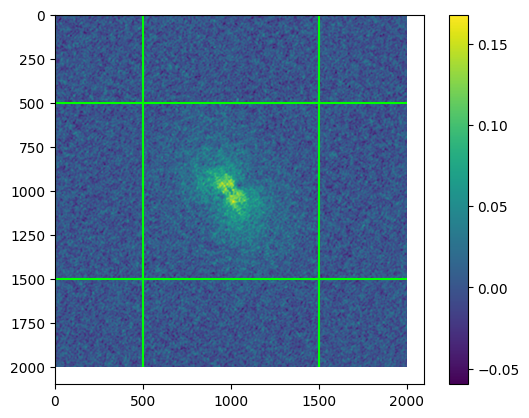

In [8]:
sumcube = np.sum(cube[20:41,:,:], axis=0)
plt.imshow(sumcube)


plt.vlines(500, 0, 2000, color='lime')
plt.vlines(1500, 0, 2000, color='lime')
plt.hlines(500, 0, 2000, color='lime')
plt.hlines(1500, 0, 2000, color='lime')
#plt.xlim(400, 1200)
#plt.ylim(400, 1200)
plt.colorbar()

In [9]:
y_lo, y_hi = 500, 1500
x_lo, x_hi = 500, 1500

subdata = hdu[0].data[..., y_lo:y_hi, x_lo:x_hi]

# Copiamos el header del cubo original. Como astropy consume BSCALE/BZERO al
# aplicar el escalado en la lectura, los re-inyectamos para que el archivo
# resultante siga siendo válido para el resto del pipeline.
header = hdu[0].header.copy()
header['BSCALE'] = 1.0
header['BZERO']  = 0.0

# Ajustamos los pixeles de referencia espaciales al nuevo origen del recorte.
if 'CRPIX1' in header:
    header['CRPIX1'] -= x_lo
if 'CRPIX2' in header:
    header['CRPIX2'] -= y_lo

new_hdu = fits.PrimaryHDU(data=subdata.astype(np.float32), header=header)

out_name = f'{CUBE_NAME}_sub.fits'
out_path = os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, out_name)
new_hdu.writeto(out_path, overwrite=True, output_verify='fix')

print('Saved:', out_name)
print('Shape:', subdata.shape)

Saved: imlup_co_sub.fits
Shape: (1, 60, 1000, 1000)


# 1. Denoising

In [7]:
method_type = 'iterative'
threshold_type = 'soft'
threshold_level = 5

In [ ]:
wavelet_denoising(
    negative=False,
    cube_name=CUBE_NAME,
    cube_type_dir=CUBE_TYPE_DIR,
    cube_dir=CUBE_DIR,
    method_type=method_type,
    threshold_type=threshold_type,
    threshold_level=threshold_level)

Channel width:  -0.34999999998586395
Number of 2D wavelet scales set to 4
Number of 1D wavelet scales set to 3

--- [ PERFORMING ITERATIVE DENOISING ] ---

----[ Denoising with ITERATIVE SOFT THRESHOLDING ]----


In [25]:
for i in range(1,3):
    wavelet_denoising(
        negative=False,
        cube_name=CUBE_NAME,
        cube_type_dir=CUBE_TYPE_DIR,
        cube_dir=CUBE_DIR,
        method_type=method_type,
        threshold_type=threshold_type,
        threshold_level=i)

Channel width:  -17.725334074420633
Number of 2D wavelet scales set to 6 (maximum value allowed by input image)
Number of 1D wavelet scales set to 5 (maximum value allowed by input image)

--- [ PERFORMING ITERATIVE DENOISING ] ---

----[ Denoising with ITERATIVE SOFT THRESHOLDING ]----

[*] Trying with plateau condition: 1 consecutive stable residuals needed for convergence


--- [ DE-NOISING ITERATION #1 ] ---

(*) Decomposing noisy data into wavelet coefficients
(*) The gradient in the first iteration is 0
(*) Reconstructing the new signal coefficients into the real space
(*) Applying the positivity constraint
(*) Repeating these steps for subsequent iterations
(*) Aperture Flux: 9.670e+00, Clean Flux: 1.519e+00, Residual STD: 1.235e-04


--- [ DE-NOISING ITERATION #2 ] ---

(*) Updating model with gradient with respect to data
(*) Calculating weights for each iteration (except #1) to account for the soft thresholding bias
(*) Aperture Flux: 1.463e+01, Clean Flux: 1.519e+00, Residua